In [5]:
from openaq import OpenAQ as aq
import pandas as pd
import geopandas
import folium
#Load API
api = aq(api_key="703567a9b637449ffb21acf96659f4a58d69761753e4e1082ab6fb84232652de")

In [6]:
#Get the locations list for india. Limit argument is to make sure it covers all the available stations in india
locations = api.locations.list(
    countries_id=9,
    limit=1000
)

In [7]:
# Convert results to a list of dictionaries for Pandas
locs_data = [loc for loc in locations.results]
df = pd.DataFrame(locs_data)

Each entry in the sensor column is a list of dictionaries. Which looks like this

[{'id': 33,
  'name': 'co µg/m³',
  'parameter': {'id': 4,
   'name': 'co',
   'units': 'µg/m³',
   'display_name': 'CO mass'}}, 
 {'id': 32,
  'name': 'no2 µg/m³',
  'parameter': {'id': 5,
   'name': 'no2',
   'units': 'µg/m³',
   'display_name': 'NO₂ mass'}},
 {'id': 31,
  'name': 'pm10 µg/m³',
  'parameter': {'id': 1,
   'name': 'pm10',
   'units': 'µg/m³',
   'display_name': 'PM10'}},
 {'id': 34,
  'name': 'pm25 µg/m³',
  'parameter': {'id': 2,
   'name': 'pm25',
   'units': 'µg/m³',
   'display_name': 'PM2.5'}}]

In [25]:
#choosing required parameters and filtering the data for locations with all 4 parameters
required = {"co", "no2", "pm10", "pm25","o3","so2"}
def has_all_required(sensor_list):
    params = {s["parameter"]["name"] for s in sensor_list}
    return required.issubset(params)

filtered_df = df[df["sensors"].apply(has_all_required)]

Found 588 locations with all 4 sensors which are CO, NO2, PM2.5, PM10, O3 and SO2

In [27]:
#An interactive map of the available locations using foleum. You might have to wait some time for it to load completely. 

filtered_df["lat"] = filtered_df["coordinates"].apply(lambda x: x["latitude"])
filtered_df["lon"] = filtered_df["coordinates"].apply(lambda x: x["longitude"])

stations = filtered_df[["name", "lat", "lon"]]

import folium

m = folium.Map(location=[22, 80], zoom_start=5)  # center on India

for _, row in stations.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=4,
        popup=row["name"],
        color="red",
        fill=True
    ).add_to(m)

m

/tmp/ipykernel_198301/4234443418.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["lat"] = filtered_df["coordinates"].apply(lambda x: x["latitude"])
/tmp/ipykernel_198301/4234443418.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["lon"] = filtered_df["coordinates"].apply(lambda x: x["longitude"])


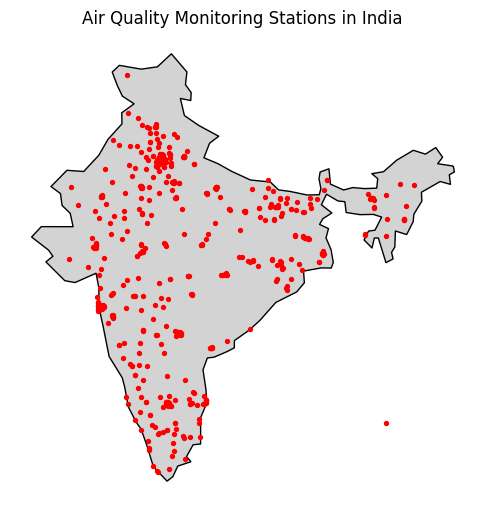

In [28]:
import geopandas as gpd
import geodatasets

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)
india = world[world["ADMIN"] == "India"]

import matplotlib.pyplot as plt

gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations.lon, stations.lat),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(6,8))

india.plot(ax=ax, color="lightgray", edgecolor="black")

gdf.plot(
    ax=ax,
    color="red",
    markersize=8
)

ax.set_title("Air Quality Monitoring Stations in India")
ax.set_axis_off()

plt.show()

## Getting data from sensors
- each sensor has a unique sensor ID
- We can get sensor IDs for each corresponding locations and use it to get the measurements

In [23]:
api.sensors.get(sensors_id=385).results
#give information about a sensor given the ID

[Sensor(id=385, name='co µg/m³', parameter=Parameter(id=4, name='co', units='µg/m³', display_name='CO mass', description=None), datetime_first=Datetime(utc='2016-02-05T14:15:00Z', local='2016-02-05T19:45:00+05:30'), datetime_last=Datetime(utc='2016-03-21T14:45:00Z', local='2016-03-21T20:15:00+05:30'), coverage=Coverage(expected_count=4, expected_interval='01:00:00', observed_count=126, observed_interval='31:30:00', percent_complete=3150.0, percent_coverage=3150.0, datetime_from=Datetime(utc='2016-02-05T14:15:00Z', local='2016-02-05T19:45:00+05:30'), datetime_to=Datetime(utc='2016-03-21T14:45:00Z', local='2016-03-21T20:15:00+05:30')), latest=LatestBase(datetime=Datetime(utc='2016-03-21T14:45:00Z', local='2016-03-21T20:15:00+05:30'), value=1300.0, coordinates=Coordinates(latitude=28.646835, longitude=77.316032)), summary=Summary(min=200.0, q02=None, q25=None, median=None, q75=None, q98=None, max=13600.0, sd=None, avg=1569.047619047619))]

In [40]:
help(api.measurements.list)

Help on method list in module openaq._sync.models.measurements:

list(sensors_id: int, data: Optional[Literal['measurements', 'hours', 'days', 'years']] = None, rollup: Optional[Literal['hourly', 'daily', 'monthly', 'yearly', 'hourofday', 'dayofweek', 'monthofyear']] = None, datetime_from: datetime.datetime | str | None = '2016-10-10', datetime_to: datetime.datetime | str | None = None, page: int = 1, limit: int = 1000) -> openaq.shared.responses.MeasurementsResponse method of openaq._sync.models.measurements.Measurements instance
    List air quality measurements based on provided filters.

    Args:
        sensors_id: The ID of the sensor for which measurements should be retrieved.
        data: The base measurement unit to query
        rollup: The period by which to rollup the base measurement data.
        datetime_from: Starting date for the measurement retrieval. Can be a datetime object or ISO-8601 formatted date or datetime string.
        datetime_to: Ending date for the mea

In [94]:
from datetime import datetime

# Get current local date and time and format it as ISO 8601 string
current_time = datetime.now().isoformat()
print(current_time)

hrly = api.measurements.list(sensors_id=1, rollup="hourly", datetime_from="2016-01-01", datetime_to="2026-01-01")
dat_list = [res for res in hrly.results]
dat = pd.DataFrame(dat_list)

2026-03-13T16:19:02.176546


In [96]:
hrly

MeasurementsResponse(headers=Headers(x_ratelimit_limit=60, x_ratelimit_remaining=59, x_ratelimit_used=1, x_ratelimit_reset=60), meta=Meta(name='openaq-api', website='/', page=1, limit=1000, found=0), results=[])

In [86]:
years = range(2016, 2026)

all_results = []

for y in years:
    hrly = api.measurements.list(
        sensors_id=385,
        rollup="hourly",
        datetime_from=f"{y}-01-01",
        datetime_to=f"{y}-12-31",
        limit=1000
    )

    all_results.extend(hrly.results)

In [139]:
import requests

url = "https://api.openaq.org/v3/sensors/12234782/measurements"

params = {
    "datetime_from": "2026-01-01",
    "limit":1000
}

headers = {
    "X-API-Key": "703567a9b637449ffb21acf96659f4a58d69761753e4e1082ab6fb84232652de"
}

r = requests.get(url, params=params, headers=headers)

data = r.json()
df = pd.json_normalize(data["results"])

In [137]:
df

""


In [116]:
filtered_df["sensors"]

4      [{'id': 12234782, 'name': 'co ppb', 'parameter...
5      [{'id': 398, 'name': 'co µg/m³', 'parameter': ...
7      [{'id': 12235605, 'name': 'co ppb', 'parameter...
8      [{'id': 386, 'name': 'co µg/m³', 'parameter': ...
10     [{'id': 14258983, 'name': 'co ppb', 'parameter...
                             ...                        
717    [{'id': 15586068, 'name': 'co ppb', 'parameter...
718    [{'id': 15645471, 'name': 'co ppb', 'parameter...
719    [{'id': 15645483, 'name': 'co ppb', 'parameter...
720    [{'id': 15645495, 'name': 'co ppb', 'parameter...
721    [{'id': 15645507, 'name': 'co ppb', 'parameter...
Name: sensors, Length: 588, dtype: object